In [21]:
%load_ext autoreload
%autoreload 1
from cyclists import Cyclist as cyc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from tqdm import tqdm
%aimport cyclists

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Homogeneous conditions for every cyclist

In [51]:
#initializing parameters for the race
#np.random.seed(42)
N=50 # number of cyclists
total_distance = 40000 # m
gamma = 0.5 # draft coeficient N/(kg*m/s)
dt = 0.1 # s
initial_stamina = 7*gamma*total_distance # minimum stamina to complete the race
x_0 = np.zeros(N) # initial positions of every racer
init_strats = np.random.choice([0,1], size = N, p=[0.9,0.1])
attack_v = 12.5 # m/s
no_attack_v = 7 # m/s
lmbd = 0.2 # update rate for strategies (choose an agent at random) events/s
#Create peloton
peloton = np.array([[cyc(stamina = initial_stamina, x0 = x_0[i], strat = init_strats[i],
                         gamma = gamma, des_threshold = 15, dt = dt, attack_v = attack_v, no_attack_v = no_attack_v),i] for i in range(N)])

## Individualism: each agent seeks to minimize the distance from the agent that is the farthest away

In [32]:
# Lists for plotting
x_history = [[] for _ in range(N)]
strat_history = [[] for _ in range(N)]
work_history = [[] for _ in range(N)]
stamina_history = [[] for _ in range(N)]
time_history = [0]
update_time = 0
# Simulation loop
while peloton.shape[0] > 0:
    for i in range(peloton.shape[0]-1,-1,-1):
        peloton[i,0].step()
        x_history[peloton[i,1]].append(peloton[i,0].x1)
        strat_history[peloton[i,1]].append(peloton[i,0].strat)
        work_history[peloton[i,1]].append(peloton[i,0].w)
        stamina_history[peloton[i,1]].append(peloton[i,0].stamina)
        if peloton[i,0].x1 >= total_distance:
            peloton = np.delete(peloton, i, axis = 0)
    time_history.append(time_history[-1] + dt)
    if time_history[-1] >= update_time:
        # Choose a random agent to update strategy
        if peloton.shape[0] > 0:
            rand_index = np.random.choice(peloton.shape[0])
            indv_payoff = 0
            # marginal payoff matrix shows how much more or less payoff an
            # agent could get with some strategy depending on the oponent's strategy
            marginal_payoff_matrix = np.array([ [0,             (attack_v - no_attack_v)*5],#NA
                                              [-(attack_v - no_attack_v)*5,  0]])#A
                                                # NA                         #A
            for j in range(peloton.shape[0]):
                if peloton[j,1] != peloton[rand_index,1]:
                    #depends on how much distance is another agent j ahead or behind of agent i currently
                    # in this scenario, the individual's payoff will be the maximum distance someone from the
                    # rest of the peloton j is ahead from i. depending of this it will either attack or not
                    payoff_i_respect_j= peloton[j,0].x1 - peloton[rand_index,0].x1 + marginal_payoff_matrix[peloton[rand_index,0].strat, peloton[j,0].strat]
                    if payoff_i_respect_j > indv_payoff:
                        indv_payoff = payoff_i_respect_j
            peloton[rand_index,0].update_strat(-indv_payoff, 0)
        update_time = time_history[-1] + np.random.exponential(scale=1/lmbd)
    





### Plotting results from simulation

100%|██████████| 50/50 [00:02<00:00, 23.20it/s]


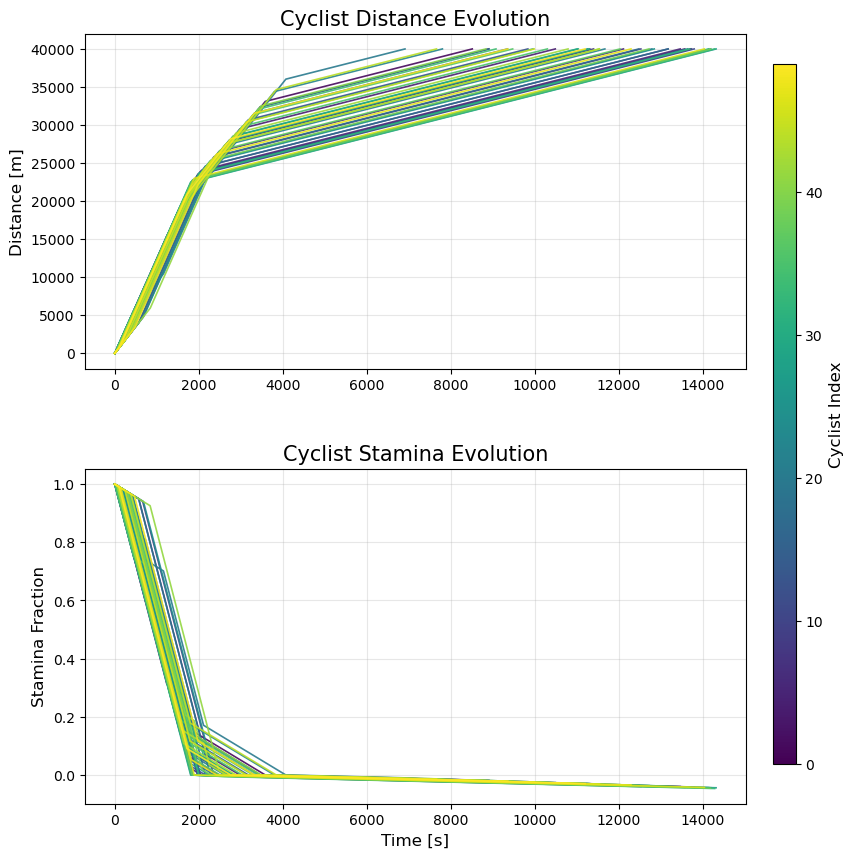

In [33]:
# ============================================
# DISTANCE + STAMINA EVOLUTION
# ============================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 10)   # reduced horizontal size
)

# Colormap
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=N-1)

# ============================================
# PLOT EACH CYCLIST
# ============================================

for i in tqdm(range(N)):

    t = np.arange(len(x_history[i])) * dt
    color = cmap(norm(i))

    # Distance
    ax1.plot(
        t,
        x_history[i],
        color=color,
        linewidth=1.2,
        alpha=0.9
    )

    # Stamina
    ax2.plot(
        t,
        np.array(stamina_history[i])/stamina_history[i][0],
        color=color,
        linewidth=1.2,
        alpha=0.9
    )

# ============================================
# LABELS
# ============================================

ax1.set_title("Cyclist Distance Evolution", fontsize=15)
ax1.set_ylabel("Distance [m]", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.set_title("Cyclist Stamina Evolution", fontsize=15)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.set_ylabel("Stamina Fraction", fontsize=12)
ax2.grid(True, alpha=0.3)

# Leave space at right for colorbar
fig.subplots_adjust(right=0.86, hspace=0.3)

# ============================================
# COLORBAR OUTSIDE PLOT
# ============================================

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Manual colorbar axis outside plots
cbar_ax = fig.add_axes([0.89, 0.15, 0.025, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Cyclist Index", fontsize=12)

plt.show()

### Plots but with strategy differentiation by color

100%|██████████| 50/50 [00:08<00:00,  6.18it/s]


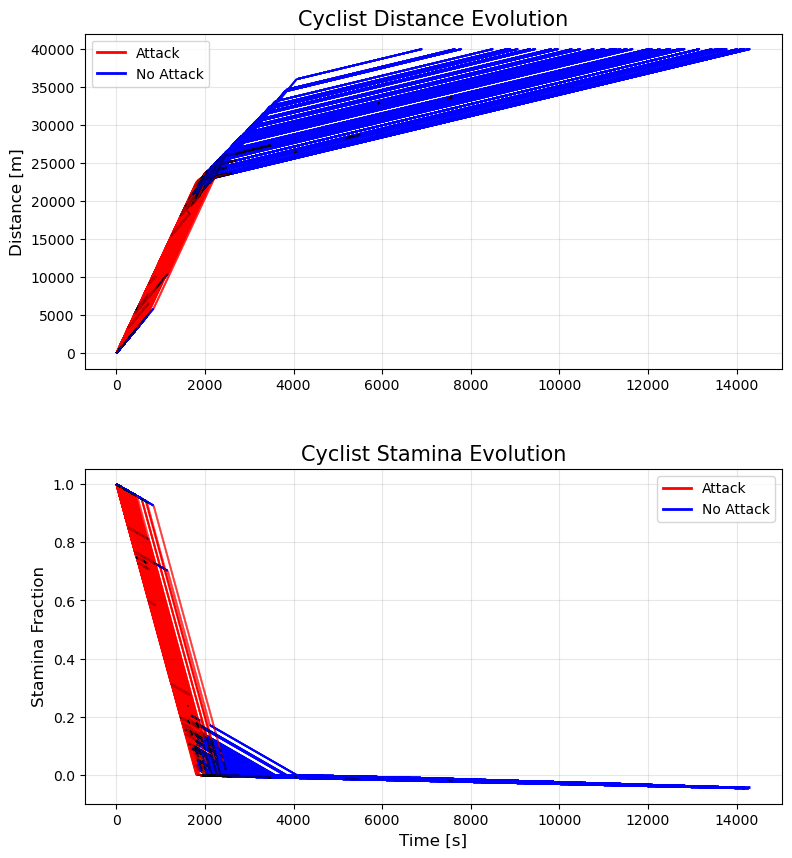

In [34]:
# ============================================
# FIGURE
# ============================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 10)
)

# ============================================
# BUILD LINE SEGMENTS
# ============================================

distance_segments = []
distance_colors = []

stamina_segments = []
stamina_colors = []

for i in tqdm(range(N)):

    t = np.arange(len(x_history[i])) * dt

    x = np.array(x_history[i])

    stamina = (
        np.array(stamina_history[i]) /
        stamina_history[i][0]
    )

    strat = np.array(strat_history[i])

    # ----------------------------------------
    # Create line segments
    # ----------------------------------------

    points_distance = np.array([t, x]).T.reshape(-1, 1, 2)
    seg_distance = np.concatenate(
        [points_distance[:-1], points_distance[1:]],
        axis=1
    )

    points_stamina = np.array([t, stamina]).T.reshape(-1, 1, 2)
    seg_stamina = np.concatenate(
        [points_stamina[:-1], points_stamina[1:]],
        axis=1
    )

    # ----------------------------------------
    # Colors by strategy
    # ----------------------------------------

    colors = np.where(
        strat[:-1] == 1,
        'red',
        'blue'
    )

    # Store
    distance_segments.extend(seg_distance)
    stamina_segments.extend(seg_stamina)

    distance_colors.extend(colors)
    stamina_colors.extend(colors)

# ============================================
# LINE COLLECTIONS
# ============================================

lc1 = LineCollection(
    distance_segments,
    colors=distance_colors,
    linewidths=1.2,
    alpha=0.9
)

lc2 = LineCollection(
    stamina_segments,
    colors=stamina_colors,
    linewidths=1.2,
    alpha=0.9
)

ax1.add_collection(lc1)
ax2.add_collection(lc2)

# Autoscale axes
ax1.autoscale()
ax2.autoscale()

# ============================================
# LABELS
# ============================================

ax1.set_title("Cyclist Distance Evolution", fontsize=15)
ax1.set_ylabel("Distance [m]", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.set_title("Cyclist Stamina Evolution", fontsize=15)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.set_ylabel("Stamina Fraction", fontsize=12)
ax2.grid(True, alpha=0.3)

# ============================================
# LEGEND
# ============================================

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Attack'),
    Line2D([0], [0], color='blue', lw=2, label='No Attack')
]

ax1.legend(handles=legend_elements, loc='upper left')
ax2.legend(handles=legend_elements, loc='upper right')

fig.subplots_adjust(hspace=0.3)

plt.show()

### Best 5 and worst 5

100%|██████████| 4/4 [00:00<00:00, 288.63it/s]


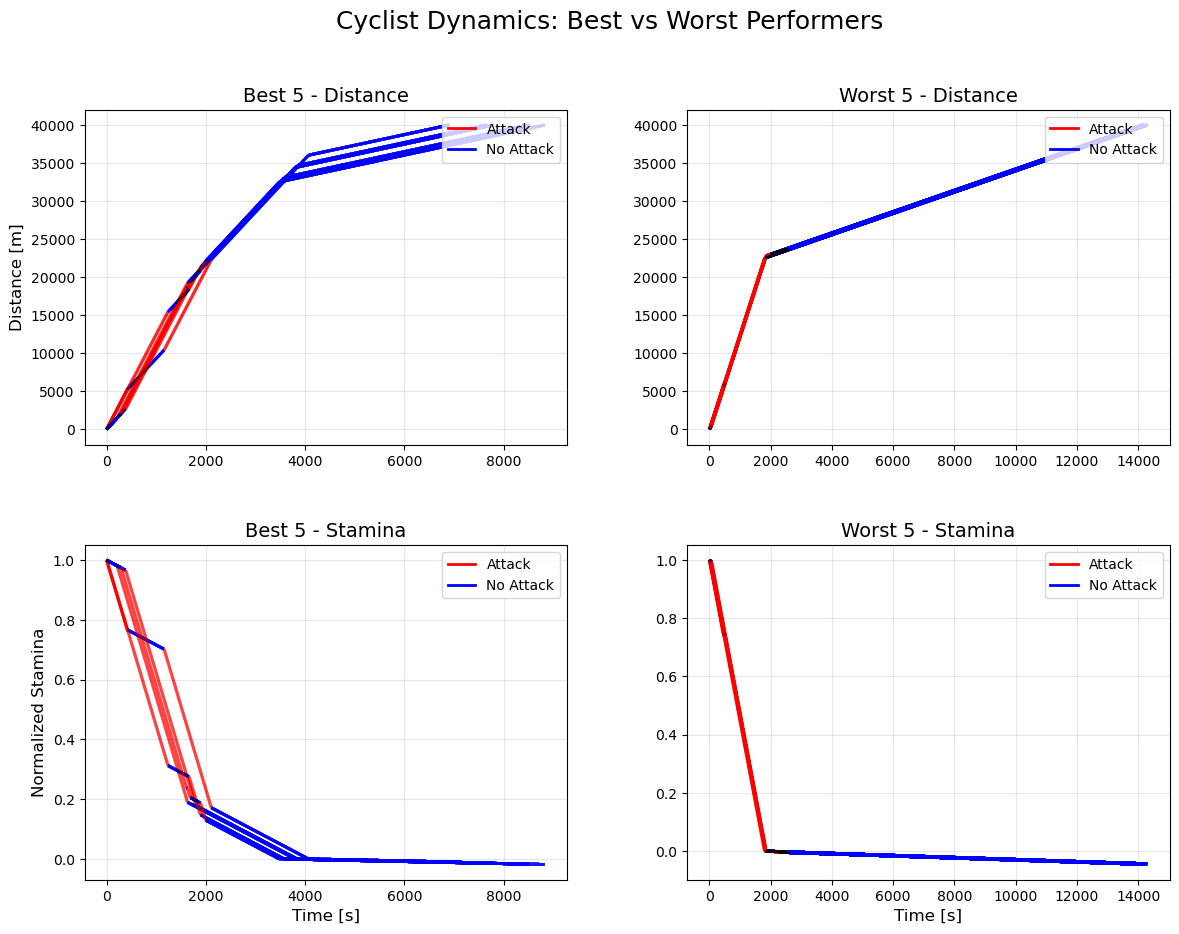

Best 5 cyclists:
Agent 20: 6909.0 s
Agent 44: 7659.1 s
Agent 22: 7800.1 s
Agent 1: 8510.7 s
Agent 40: 8832.8 s

Worst 5 cyclists:
Agent 29: 14135.1 s
Agent 38: 14182.1 s
Agent 14: 14187.0 s
Agent 33: 14279.3 s
Agent 27: 14313.4 s


In [35]:
# ============================================
# FINISH TIMES
# ============================================

finish_times = np.array([
    len(x_history[i]) * dt
    for i in range(N)
])

# Best and worst cyclists
best_idx = np.argsort(finish_times)[:5]
worst_idx = np.argsort(finish_times)[-5:]

# ============================================
# FIGURE
# ============================================

fig, axs = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharex=False
)

# Axes
ax_dist_best = axs[0, 0]
ax_stam_best = axs[1, 0]

ax_dist_worst = axs[0, 1]
ax_stam_worst = axs[1, 1]

# ============================================
# FUNCTION TO BUILD COLLECTIONS
# ============================================

def build_collections(indices):

    distance_segments = []
    distance_colors = []

    stamina_segments = []
    stamina_colors = []

    for i in tqdm(indices):

        t = np.arange(len(x_history[i])) * dt

        x = np.array(x_history[i])

        stamina = (
            np.array(stamina_history[i]) /
            stamina_history[i][0]
        )

        strat = np.array(strat_history[i])

        # ------------------------------------
        # DISTANCE SEGMENTS
        # ------------------------------------

        points_distance = np.array([t, x]).T.reshape(-1, 1, 2)

        seg_distance = np.concatenate(
            [points_distance[:-1], points_distance[1:]],
            axis=1
        )

        # ------------------------------------
        # STAMINA SEGMENTS
        # ------------------------------------

        points_stamina = np.array([t, stamina]).T.reshape(-1, 1, 2)

        seg_stamina = np.concatenate(
            [points_stamina[:-1], points_stamina[1:]],
            axis=1
        )

        # ------------------------------------
        # STRATEGY COLORS
        # ------------------------------------

        colors = np.where(
            strat[:-1] == 1,
            'red',
            'blue'
        )

        # Store
        distance_segments.extend(seg_distance)
        stamina_segments.extend(seg_stamina)

        distance_colors.extend(colors)
        stamina_colors.extend(colors)

    return (
        distance_segments,
        distance_colors,
        stamina_segments,
        stamina_colors
    )

# ============================================
# BUILD BEST COLLECTIONS
# ============================================

(
    best_dist_seg,
    best_dist_col,
    best_stam_seg,
    best_stam_col
) = build_collections(best_idx)

# ============================================
# BUILD WORST COLLECTIONS
# ============================================

(
    worst_dist_seg,
    worst_dist_col,
    worst_stam_seg,
    worst_stam_col
) = build_collections(worst_idx)

# ============================================
# ADD COLLECTIONS
# ============================================

# Best distance
ax_dist_best.add_collection(
    LineCollection(
        best_dist_seg,
        colors=best_dist_col,
        linewidths=2,
        alpha=0.9
    )
)

# Best stamina
ax_stam_best.add_collection(
    LineCollection(
        best_stam_seg,
        colors=best_stam_col,
        linewidths=2,
        alpha=0.9
    )
)

# Worst distance
ax_dist_worst.add_collection(
    LineCollection(
        worst_dist_seg,
        colors=worst_dist_col,
        linewidths=2,
        alpha=0.9
    )
)

# Worst stamina
ax_stam_worst.add_collection(
    LineCollection(
        worst_stam_seg,
        colors=worst_stam_col,
        linewidths=2,
        alpha=0.9
    )
)

# ============================================
# AUTOSCALE
# ============================================

for ax in tqdm(axs.flat):
    ax.autoscale()
    ax.grid(True, alpha=0.3)

# ============================================
# TITLES
# ============================================

ax_dist_best.set_title("Best 5 - Distance", fontsize=14)
ax_stam_best.set_title("Best 5 - Stamina", fontsize=14)

ax_dist_worst.set_title("Worst 5 - Distance", fontsize=14)
ax_stam_worst.set_title("Worst 5 - Stamina", fontsize=14)

# ============================================
# LABELS
# ============================================

ax_dist_best.set_ylabel("Distance [m]", fontsize=12)
ax_stam_best.set_ylabel("Normalized Stamina", fontsize=12)

ax_stam_best.set_xlabel("Time [s]", fontsize=12)
ax_stam_worst.set_xlabel("Time [s]", fontsize=12)

# ============================================
# LEGEND
# ============================================

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Attack'),
    Line2D([0], [0], color='blue', lw=2, label='No Attack')
]

for ax in tqdm(axs.flat):
    ax.legend(handles=legend_elements)

# ============================================
# LAYOUT
# ============================================

fig.suptitle(
    "Cyclist Dynamics: Best vs Worst Performers",
    fontsize=18
)

fig.subplots_adjust(
    hspace=0.3,
    wspace=0.25
)

plt.show()

# ============================================
# PRINT RANKINGS
# ============================================

print("Best 5 cyclists:")
for idx in best_idx:
    print(f"Agent {idx}: {finish_times[idx]:.1f} s")

print("\nWorst 5 cyclists:")
for idx in worst_idx:
    print(f"Agent {idx}: {finish_times[idx]:.1f} s")

## Individualism: Agents compare their current payoff compared to the rest of the group

In [43]:
# Lists for plotting
x_history = [[] for _ in range(N)]
strat_history = [[] for _ in range(N)]
work_history = [[] for _ in range(N)]
stamina_history = [[] for _ in range(N)]
time_history = [0]
update_time = 0
# Simulation loop
while peloton.shape[0] > 0:
    for i in range(peloton.shape[0]-1,-1,-1):
        peloton[i,0].step()
        x_history[peloton[i,1]].append(peloton[i,0].x1)
        strat_history[peloton[i,1]].append(peloton[i,0].strat)
        work_history[peloton[i,1]].append(peloton[i,0].w)
        stamina_history[peloton[i,1]].append(peloton[i,0].stamina)
        if peloton[i,0].x1 >= total_distance:
            peloton = np.delete(peloton, i, axis = 0)
    time_history.append(time_history[-1] + dt)
    if time_history[-1] >= update_time:
        # Choose a random agent to update strategy
        if peloton.shape[0] > 0:
            rand_index = np.random.choice(peloton.shape[0])
            # Calculate payoff of the chosen agent and average payoff of the population
            indv_payoff = 0
            # counter of agents that are attacking
            count_A = 0
            # marginal payoff matrix shows how much more or less payoff an
            # agent could get with some strategy depending on the oponent's strategy
            marginal_payoff_matrix = np.array([ [0,             (attack_v - no_attack_v)*5],#NA
                                              [-(attack_v - no_attack_v)*5,  0]])#A
                                                # NA                         #A
            for j in range(peloton.shape[0]):
                count_A += peloton[j, 0].strat
                if peloton[j,1] != peloton[rand_index,1]:
                    # 
                    payoff_i_respect_j= marginal_payoff_matrix[peloton[rand_index,0].strat, peloton[j,0].strat] 
                    indv_payoff += payoff_i_respect_j
            indv_payoff /= peloton.shape[0] -1
            population_proportions = np.array([1-count_A/peloton.shape[0], count_A/peloton.shape[0]])
            average_payoff = np.dot(population_proportions, np.dot(marginal_payoff_matrix, population_proportions))
            peloton[rand_index,0].update_strat(indv_payoff, average_payoff +15)
        update_time = time_history[-1] + np.random.exponential(scale=1/lmbd)
    





### Plotting results from simulation

100%|██████████| 50/50 [00:01<00:00, 39.78it/s]


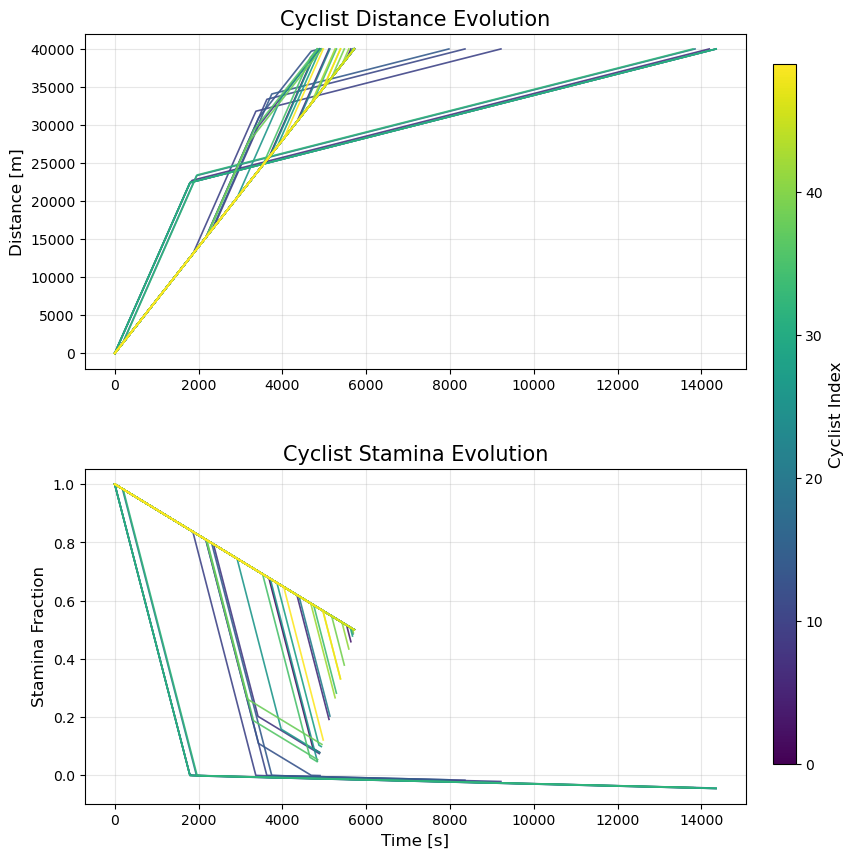

In [44]:
# ============================================
# DISTANCE + STAMINA EVOLUTION
# ============================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 10)   # reduced horizontal size
)

# Colormap
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=N-1)

# ============================================
# PLOT EACH CYCLIST
# ============================================

for i in tqdm(range(N)):

    t = np.arange(len(x_history[i])) * dt
    color = cmap(norm(i))

    # Distance
    ax1.plot(
        t,
        x_history[i],
        color=color,
        linewidth=1.2,
        alpha=0.9
    )

    # Stamina
    ax2.plot(
        t,
        np.array(stamina_history[i])/stamina_history[i][0],
        color=color,
        linewidth=1.2,
        alpha=0.9
    )

# ============================================
# LABELS
# ============================================

ax1.set_title("Cyclist Distance Evolution", fontsize=15)
ax1.set_ylabel("Distance [m]", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.set_title("Cyclist Stamina Evolution", fontsize=15)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.set_ylabel("Stamina Fraction", fontsize=12)
ax2.grid(True, alpha=0.3)

# Leave space at right for colorbar
fig.subplots_adjust(right=0.86, hspace=0.3)

# ============================================
# COLORBAR OUTSIDE PLOT
# ============================================

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Manual colorbar axis outside plots
cbar_ax = fig.add_axes([0.89, 0.15, 0.025, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Cyclist Index", fontsize=12)

plt.show()

### Plots but with strategy differentiation by color

100%|██████████| 50/50 [00:05<00:00,  9.17it/s]


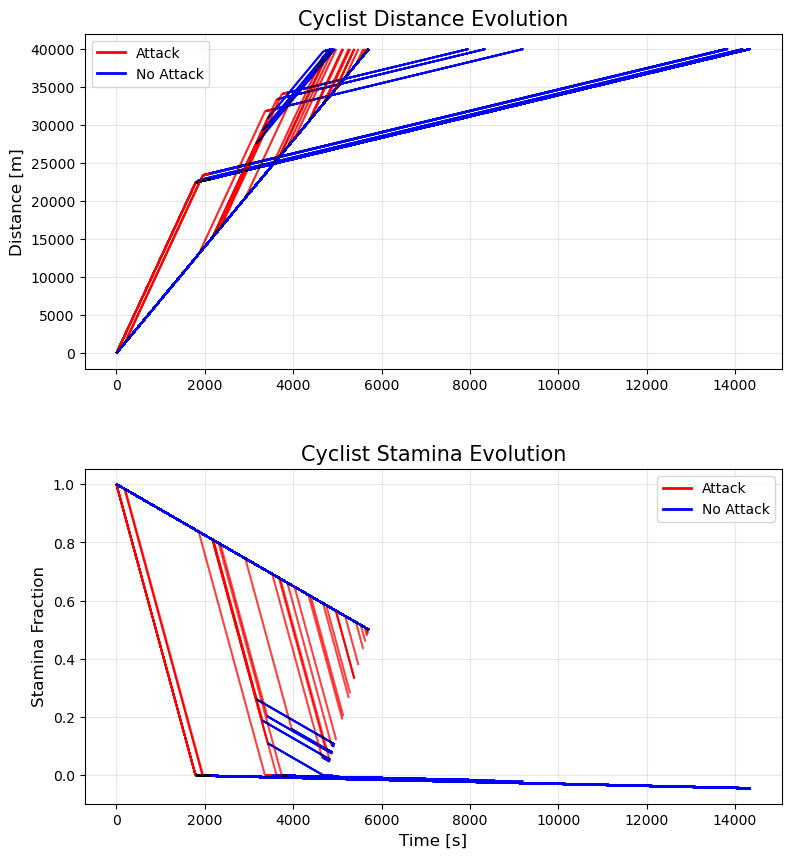

In [45]:
# ============================================
# FIGURE
# ============================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 10)
)

# ============================================
# BUILD LINE SEGMENTS
# ============================================

distance_segments = []
distance_colors = []

stamina_segments = []
stamina_colors = []

for i in tqdm(range(N)):

    t = np.arange(len(x_history[i])) * dt

    x = np.array(x_history[i])

    stamina = (
        np.array(stamina_history[i]) /
        stamina_history[i][0]
    )

    strat = np.array(strat_history[i])

    # ----------------------------------------
    # Create line segments
    # ----------------------------------------

    points_distance = np.array([t, x]).T.reshape(-1, 1, 2)
    seg_distance = np.concatenate(
        [points_distance[:-1], points_distance[1:]],
        axis=1
    )

    points_stamina = np.array([t, stamina]).T.reshape(-1, 1, 2)
    seg_stamina = np.concatenate(
        [points_stamina[:-1], points_stamina[1:]],
        axis=1
    )

    # ----------------------------------------
    # Colors by strategy
    # ----------------------------------------

    colors = np.where(
        strat[:-1] == 1,
        'red',
        'blue'
    )

    # Store
    distance_segments.extend(seg_distance)
    stamina_segments.extend(seg_stamina)

    distance_colors.extend(colors)
    stamina_colors.extend(colors)

# ============================================
# LINE COLLECTIONS
# ============================================

lc1 = LineCollection(
    distance_segments,
    colors=distance_colors,
    linewidths=1.2,
    alpha=0.9
)

lc2 = LineCollection(
    stamina_segments,
    colors=stamina_colors,
    linewidths=1.2,
    alpha=0.9
)

ax1.add_collection(lc1)
ax2.add_collection(lc2)

# Autoscale axes
ax1.autoscale()
ax2.autoscale()

# ============================================
# LABELS
# ============================================

ax1.set_title("Cyclist Distance Evolution", fontsize=15)
ax1.set_ylabel("Distance [m]", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.set_title("Cyclist Stamina Evolution", fontsize=15)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.set_ylabel("Stamina Fraction", fontsize=12)
ax2.grid(True, alpha=0.3)

# ============================================
# LEGEND
# ============================================

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Attack'),
    Line2D([0], [0], color='blue', lw=2, label='No Attack')
]

ax1.legend(handles=legend_elements, loc='upper left')
ax2.legend(handles=legend_elements, loc='upper right')

fig.subplots_adjust(hspace=0.3)

plt.show()

### Best 5 and worst 5

100%|██████████| 4/4 [00:00<00:00, 342.76it/s]


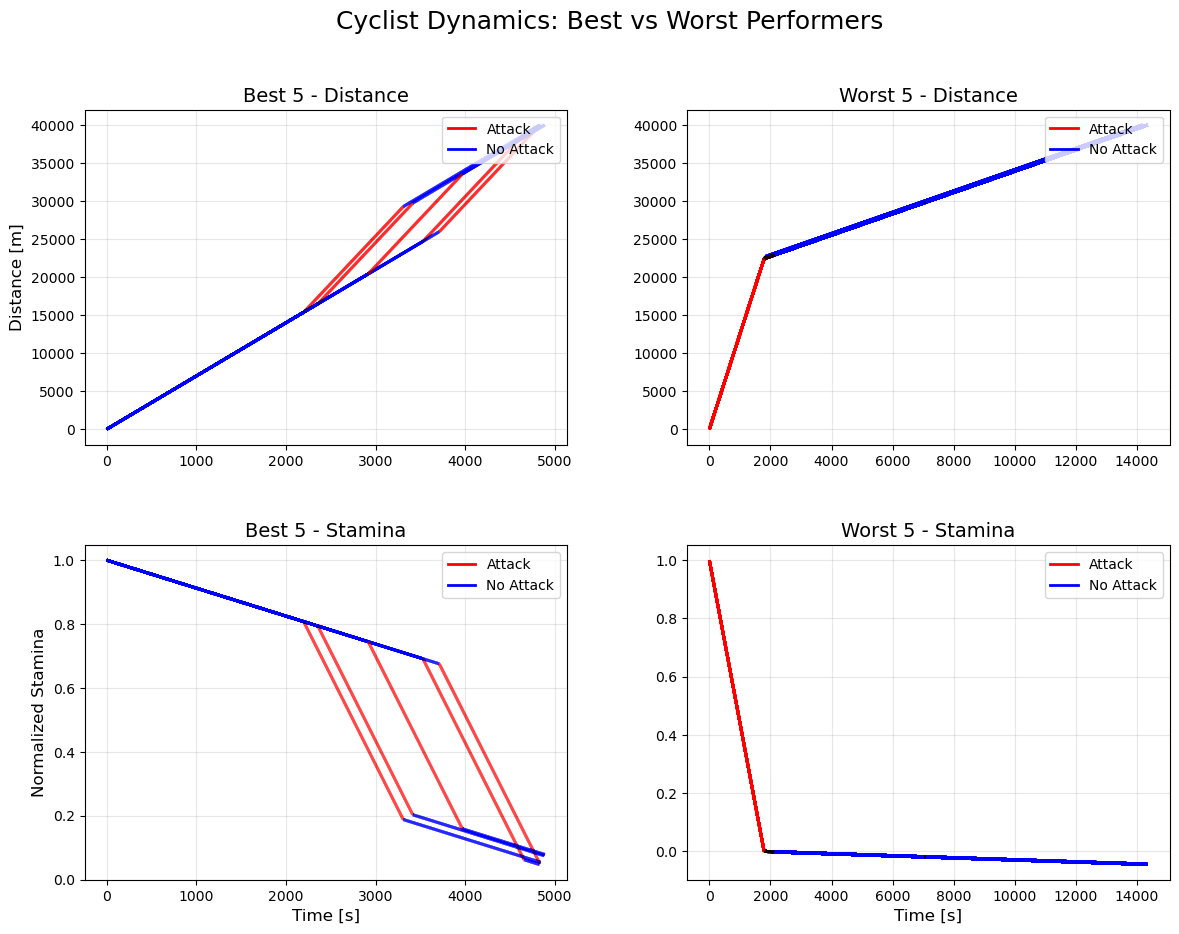

Best 5 cyclists:
Agent 35: 4828.0 s
Agent 25: 4833.2 s
Agent 36: 4841.2 s
Agent 8: 4881.7 s
Agent 26: 4888.9 s

Worst 5 cyclists:
Agent 7: 14185.3 s
Agent 23: 14348.4 s
Agent 5: 14348.4 s
Agent 31: 14348.4 s
Agent 30: 14348.4 s


In [46]:
# ============================================
# FINISH TIMES
# ============================================

finish_times = np.array([
    len(x_history[i]) * dt
    for i in range(N)
])

# Best and worst cyclists
best_idx = np.argsort(finish_times)[:5]
worst_idx = np.argsort(finish_times)[-5:]

# ============================================
# FIGURE
# ============================================

fig, axs = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharex=False
)

# Axes
ax_dist_best = axs[0, 0]
ax_stam_best = axs[1, 0]

ax_dist_worst = axs[0, 1]
ax_stam_worst = axs[1, 1]

# ============================================
# FUNCTION TO BUILD COLLECTIONS
# ============================================

def build_collections(indices):

    distance_segments = []
    distance_colors = []

    stamina_segments = []
    stamina_colors = []

    for i in tqdm(indices):

        t = np.arange(len(x_history[i])) * dt

        x = np.array(x_history[i])

        stamina = (
            np.array(stamina_history[i]) /
            stamina_history[i][0]
        )

        strat = np.array(strat_history[i])

        # ------------------------------------
        # DISTANCE SEGMENTS
        # ------------------------------------

        points_distance = np.array([t, x]).T.reshape(-1, 1, 2)

        seg_distance = np.concatenate(
            [points_distance[:-1], points_distance[1:]],
            axis=1
        )

        # ------------------------------------
        # STAMINA SEGMENTS
        # ------------------------------------

        points_stamina = np.array([t, stamina]).T.reshape(-1, 1, 2)

        seg_stamina = np.concatenate(
            [points_stamina[:-1], points_stamina[1:]],
            axis=1
        )

        # ------------------------------------
        # STRATEGY COLORS
        # ------------------------------------

        colors = np.where(
            strat[:-1] == 1,
            'red',
            'blue'
        )

        # Store
        distance_segments.extend(seg_distance)
        stamina_segments.extend(seg_stamina)

        distance_colors.extend(colors)
        stamina_colors.extend(colors)

    return (
        distance_segments,
        distance_colors,
        stamina_segments,
        stamina_colors
    )

# ============================================
# BUILD BEST COLLECTIONS
# ============================================

(
    best_dist_seg,
    best_dist_col,
    best_stam_seg,
    best_stam_col
) = build_collections(best_idx)

# ============================================
# BUILD WORST COLLECTIONS
# ============================================

(
    worst_dist_seg,
    worst_dist_col,
    worst_stam_seg,
    worst_stam_col
) = build_collections(worst_idx)

# ============================================
# ADD COLLECTIONS
# ============================================

# Best distance
ax_dist_best.add_collection(
    LineCollection(
        best_dist_seg,
        colors=best_dist_col,
        linewidths=2,
        alpha=0.9
    )
)

# Best stamina
ax_stam_best.add_collection(
    LineCollection(
        best_stam_seg,
        colors=best_stam_col,
        linewidths=2,
        alpha=0.9
    )
)

# Worst distance
ax_dist_worst.add_collection(
    LineCollection(
        worst_dist_seg,
        colors=worst_dist_col,
        linewidths=2,
        alpha=0.9
    )
)

# Worst stamina
ax_stam_worst.add_collection(
    LineCollection(
        worst_stam_seg,
        colors=worst_stam_col,
        linewidths=2,
        alpha=0.9
    )
)

# ============================================
# AUTOSCALE
# ============================================

for ax in tqdm(axs.flat):
    ax.autoscale()
    ax.grid(True, alpha=0.3)

# ============================================
# TITLES
# ============================================

ax_dist_best.set_title("Best 5 - Distance", fontsize=14)
ax_stam_best.set_title("Best 5 - Stamina", fontsize=14)

ax_dist_worst.set_title("Worst 5 - Distance", fontsize=14)
ax_stam_worst.set_title("Worst 5 - Stamina", fontsize=14)

# ============================================
# LABELS
# ============================================

ax_dist_best.set_ylabel("Distance [m]", fontsize=12)
ax_stam_best.set_ylabel("Normalized Stamina", fontsize=12)

ax_stam_best.set_xlabel("Time [s]", fontsize=12)
ax_stam_worst.set_xlabel("Time [s]", fontsize=12)

# ============================================
# LEGEND
# ============================================

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Attack'),
    Line2D([0], [0], color='blue', lw=2, label='No Attack')
]

for ax in tqdm(axs.flat):
    ax.legend(handles=legend_elements)

# ============================================
# LAYOUT
# ============================================

fig.suptitle(
    "Cyclist Dynamics: Best vs Worst Performers",
    fontsize=18
)

fig.subplots_adjust(
    hspace=0.3,
    wspace=0.25
)

plt.show()

# ============================================
# PRINT RANKINGS
# ============================================

print("Best 5 cyclists:")
for idx in best_idx:
    print(f"Agent {idx}: {finish_times[idx]:.1f} s")

print("\nWorst 5 cyclists:")
for idx in worst_idx:
    print(f"Agent {idx}: {finish_times[idx]:.1f} s")

## Individualism: Agents compare their current payoff compared to the rest of the group but payoff increases suddenly on last km of the race

In [52]:
# Lists for plotting
x_history = [[] for _ in range(N)]
strat_history = [[] for _ in range(N)]
work_history = [[] for _ in range(N)]
stamina_history = [[] for _ in range(N)]
time_history = [0]
update_time = 0
# Simulation loop
while peloton.shape[0] > 0:
    for i in range(peloton.shape[0]-1,-1,-1):
        peloton[i,0].step()
        x_history[peloton[i,1]].append(peloton[i,0].x1)
        strat_history[peloton[i,1]].append(peloton[i,0].strat)
        work_history[peloton[i,1]].append(peloton[i,0].w)
        stamina_history[peloton[i,1]].append(peloton[i,0].stamina)
        if peloton[i,0].x1 >= total_distance:
            peloton = np.delete(peloton, i, axis = 0)
    time_history.append(time_history[-1] + dt)
    if time_history[-1] >= update_time:
        # Choose a random agent to update strategy
        if peloton.shape[0] > 0:
            rand_index = np.random.choice(peloton.shape[0])
            # Calculate payoff of the chosen agent and average payoff of the population
            indv_payoff = 0
            # counter of agents that are attacking
            count_A = 0
            # marginal payoff matrix shows how much more or less payoff an
            # agent could get with some strategy depending on the oponent's strategy
            marginal_payoff_matrix = np.array([ [0,             (attack_v - no_attack_v)*5],#NA
                                              [-(attack_v - no_attack_v)*5,  0]])#A
                                                # NA                         #A
            for j in range(peloton.shape[0]):
                count_A += peloton[j, 0].strat
                if peloton[j,1] != peloton[rand_index,1]:
                    # 
                    payoff_i_respect_j= marginal_payoff_matrix[peloton[rand_index,0].strat, peloton[j,0].strat] 
                    indv_payoff += payoff_i_respect_j
            indv_payoff /= peloton.shape[0] -1
            population_proportions = np.array([1-count_A/peloton.shape[0], count_A/peloton.shape[0]])
            average_payoff = np.dot(population_proportions, np.dot(marginal_payoff_matrix, population_proportions))
            last_km_bonus = 100*np.exp(-(total_distance - peloton[rand_index,0].x1)**2/(2500**2))
            peloton[rand_index,0].update_strat(indv_payoff, average_payoff +15 + last_km_bonus)
        update_time = time_history[-1] + np.random.exponential(scale=1/lmbd)
    





### Plotting results from simulation

100%|██████████| 50/50 [00:01<00:00, 37.36it/s]


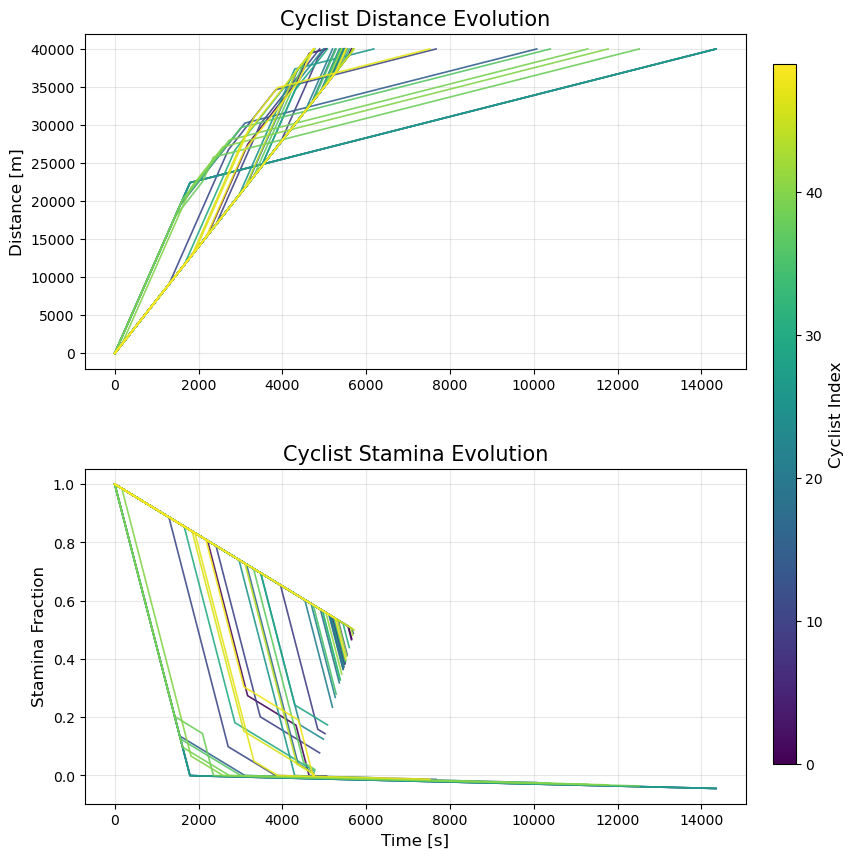

In [53]:
# ============================================
# DISTANCE + STAMINA EVOLUTION
# ============================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 10)   # reduced horizontal size
)

# Colormap
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=N-1)

# ============================================
# PLOT EACH CYCLIST
# ============================================

for i in tqdm(range(N)):

    t = np.arange(len(x_history[i])) * dt
    color = cmap(norm(i))

    # Distance
    ax1.plot(
        t,
        x_history[i],
        color=color,
        linewidth=1.2,
        alpha=0.9
    )

    # Stamina
    ax2.plot(
        t,
        np.array(stamina_history[i])/stamina_history[i][0],
        color=color,
        linewidth=1.2,
        alpha=0.9
    )

# ============================================
# LABELS
# ============================================

ax1.set_title("Cyclist Distance Evolution", fontsize=15)
ax1.set_ylabel("Distance [m]", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.set_title("Cyclist Stamina Evolution", fontsize=15)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.set_ylabel("Stamina Fraction", fontsize=12)
ax2.grid(True, alpha=0.3)

# Leave space at right for colorbar
fig.subplots_adjust(right=0.86, hspace=0.3)

# ============================================
# COLORBAR OUTSIDE PLOT
# ============================================

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Manual colorbar axis outside plots
cbar_ax = fig.add_axes([0.89, 0.15, 0.025, 0.7])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Cyclist Index", fontsize=12)

plt.show()

### Plots but with strategy differentiation by color

100%|██████████| 50/50 [00:04<00:00, 11.04it/s]


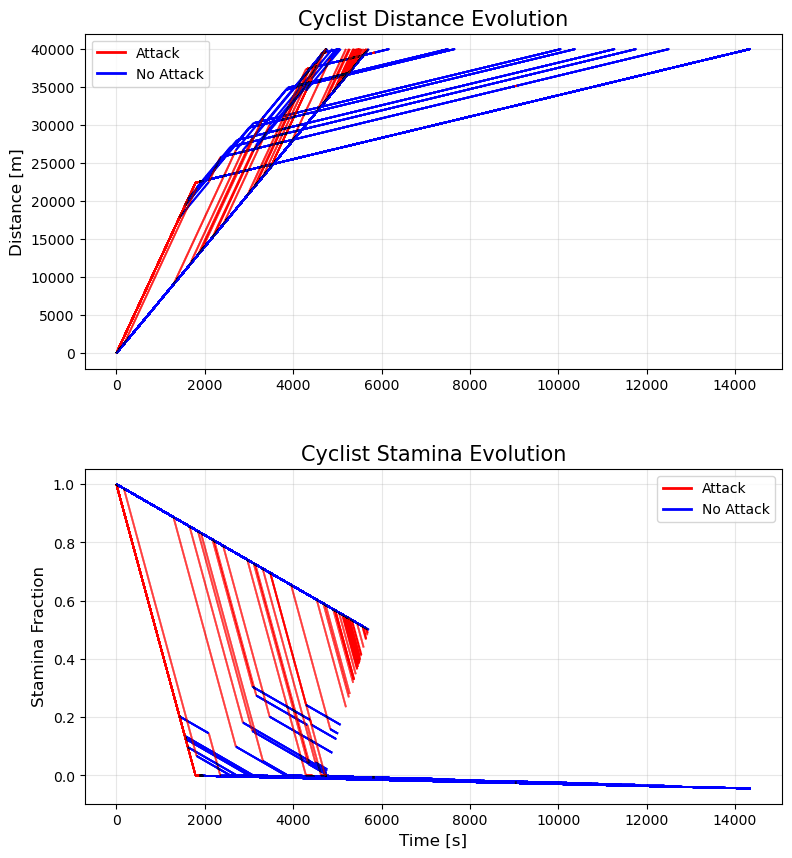

In [54]:
# ============================================
# FIGURE
# ============================================

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 10)
)

# ============================================
# BUILD LINE SEGMENTS
# ============================================

distance_segments = []
distance_colors = []

stamina_segments = []
stamina_colors = []

for i in tqdm(range(N)):

    t = np.arange(len(x_history[i])) * dt

    x = np.array(x_history[i])

    stamina = (
        np.array(stamina_history[i]) /
        stamina_history[i][0]
    )

    strat = np.array(strat_history[i])

    # ----------------------------------------
    # Create line segments
    # ----------------------------------------

    points_distance = np.array([t, x]).T.reshape(-1, 1, 2)
    seg_distance = np.concatenate(
        [points_distance[:-1], points_distance[1:]],
        axis=1
    )

    points_stamina = np.array([t, stamina]).T.reshape(-1, 1, 2)
    seg_stamina = np.concatenate(
        [points_stamina[:-1], points_stamina[1:]],
        axis=1
    )

    # ----------------------------------------
    # Colors by strategy
    # ----------------------------------------

    colors = np.where(
        strat[:-1] == 1,
        'red',
        'blue'
    )

    # Store
    distance_segments.extend(seg_distance)
    stamina_segments.extend(seg_stamina)

    distance_colors.extend(colors)
    stamina_colors.extend(colors)

# ============================================
# LINE COLLECTIONS
# ============================================

lc1 = LineCollection(
    distance_segments,
    colors=distance_colors,
    linewidths=1.2,
    alpha=0.9
)

lc2 = LineCollection(
    stamina_segments,
    colors=stamina_colors,
    linewidths=1.2,
    alpha=0.9
)

ax1.add_collection(lc1)
ax2.add_collection(lc2)

# Autoscale axes
ax1.autoscale()
ax2.autoscale()

# ============================================
# LABELS
# ============================================

ax1.set_title("Cyclist Distance Evolution", fontsize=15)
ax1.set_ylabel("Distance [m]", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.set_title("Cyclist Stamina Evolution", fontsize=15)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.set_ylabel("Stamina Fraction", fontsize=12)
ax2.grid(True, alpha=0.3)

# ============================================
# LEGEND
# ============================================

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Attack'),
    Line2D([0], [0], color='blue', lw=2, label='No Attack')
]

ax1.legend(handles=legend_elements, loc='upper left')
ax2.legend(handles=legend_elements, loc='upper right')

fig.subplots_adjust(hspace=0.3)

plt.show()

### Best 5 and worst 5

100%|██████████| 4/4 [00:00<00:00, 1165.98it/s]


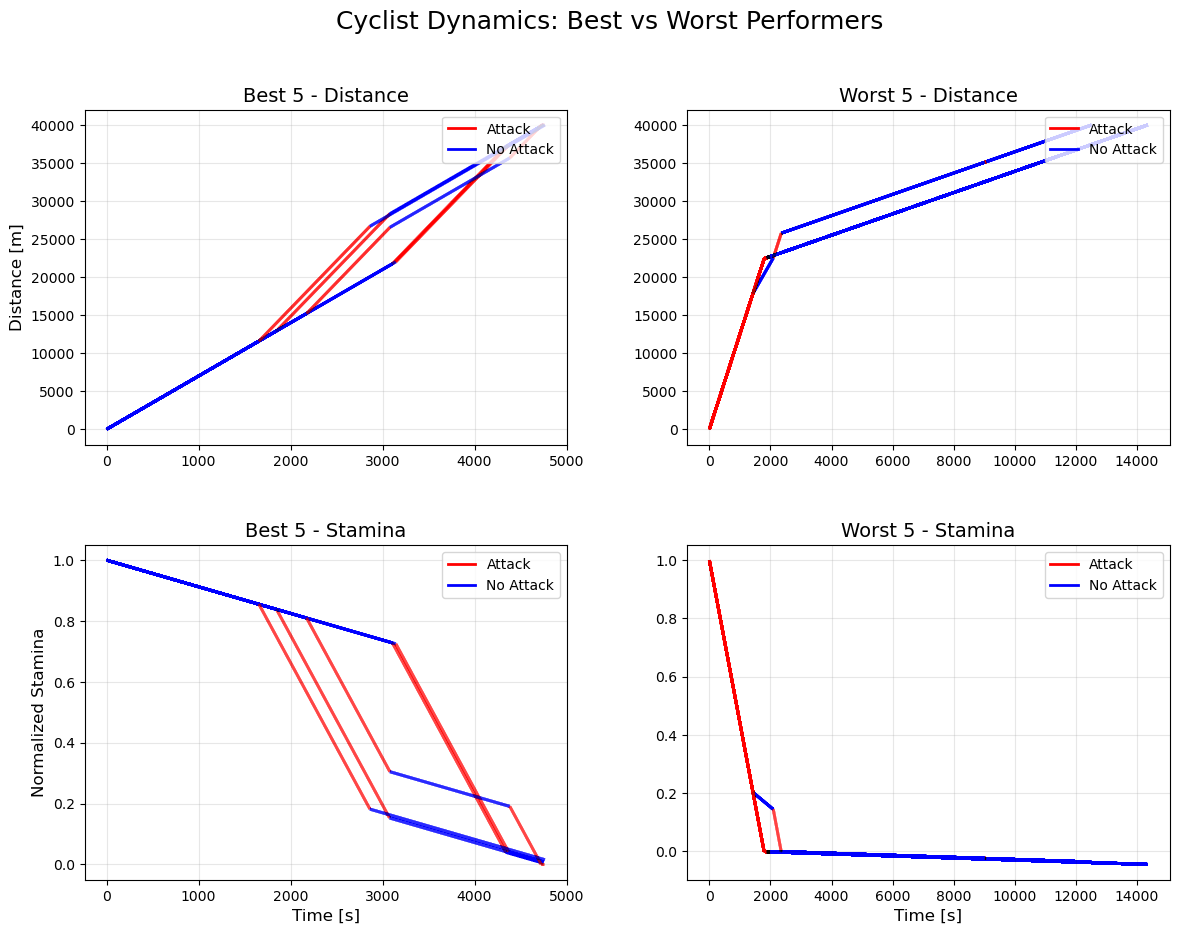

Best 5 cyclists:
Agent 44: 4744.7 s
Agent 46: 4748.3 s
Agent 17: 4751.8 s
Agent 48: 4759.4 s
Agent 30: 4765.6 s

Worst 5 cyclists:
Agent 38: 12514.6 s
Agent 16: 14348.4 s
Agent 8: 14348.4 s
Agent 25: 14348.4 s
Agent 27: 14348.4 s


In [55]:
# ============================================
# FINISH TIMES
# ============================================

finish_times = np.array([
    len(x_history[i]) * dt
    for i in range(N)
])

# Best and worst cyclists
best_idx = np.argsort(finish_times)[:5]
worst_idx = np.argsort(finish_times)[-5:]

# ============================================
# FIGURE
# ============================================

fig, axs = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharex=False
)

# Axes
ax_dist_best = axs[0, 0]
ax_stam_best = axs[1, 0]

ax_dist_worst = axs[0, 1]
ax_stam_worst = axs[1, 1]

# ============================================
# FUNCTION TO BUILD COLLECTIONS
# ============================================

def build_collections(indices):

    distance_segments = []
    distance_colors = []

    stamina_segments = []
    stamina_colors = []

    for i in tqdm(indices):

        t = np.arange(len(x_history[i])) * dt

        x = np.array(x_history[i])

        stamina = (
            np.array(stamina_history[i]) /
            stamina_history[i][0]
        )

        strat = np.array(strat_history[i])

        # ------------------------------------
        # DISTANCE SEGMENTS
        # ------------------------------------

        points_distance = np.array([t, x]).T.reshape(-1, 1, 2)

        seg_distance = np.concatenate(
            [points_distance[:-1], points_distance[1:]],
            axis=1
        )

        # ------------------------------------
        # STAMINA SEGMENTS
        # ------------------------------------

        points_stamina = np.array([t, stamina]).T.reshape(-1, 1, 2)

        seg_stamina = np.concatenate(
            [points_stamina[:-1], points_stamina[1:]],
            axis=1
        )

        # ------------------------------------
        # STRATEGY COLORS
        # ------------------------------------

        colors = np.where(
            strat[:-1] == 1,
            'red',
            'blue'
        )

        # Store
        distance_segments.extend(seg_distance)
        stamina_segments.extend(seg_stamina)

        distance_colors.extend(colors)
        stamina_colors.extend(colors)

    return (
        distance_segments,
        distance_colors,
        stamina_segments,
        stamina_colors
    )

# ============================================
# BUILD BEST COLLECTIONS
# ============================================

(
    best_dist_seg,
    best_dist_col,
    best_stam_seg,
    best_stam_col
) = build_collections(best_idx)

# ============================================
# BUILD WORST COLLECTIONS
# ============================================

(
    worst_dist_seg,
    worst_dist_col,
    worst_stam_seg,
    worst_stam_col
) = build_collections(worst_idx)

# ============================================
# ADD COLLECTIONS
# ============================================

# Best distance
ax_dist_best.add_collection(
    LineCollection(
        best_dist_seg,
        colors=best_dist_col,
        linewidths=2,
        alpha=0.9
    )
)

# Best stamina
ax_stam_best.add_collection(
    LineCollection(
        best_stam_seg,
        colors=best_stam_col,
        linewidths=2,
        alpha=0.9
    )
)

# Worst distance
ax_dist_worst.add_collection(
    LineCollection(
        worst_dist_seg,
        colors=worst_dist_col,
        linewidths=2,
        alpha=0.9
    )
)

# Worst stamina
ax_stam_worst.add_collection(
    LineCollection(
        worst_stam_seg,
        colors=worst_stam_col,
        linewidths=2,
        alpha=0.9
    )
)

# ============================================
# AUTOSCALE
# ============================================

for ax in tqdm(axs.flat):
    ax.autoscale()
    ax.grid(True, alpha=0.3)

# ============================================
# TITLES
# ============================================

ax_dist_best.set_title("Best 5 - Distance", fontsize=14)
ax_stam_best.set_title("Best 5 - Stamina", fontsize=14)

ax_dist_worst.set_title("Worst 5 - Distance", fontsize=14)
ax_stam_worst.set_title("Worst 5 - Stamina", fontsize=14)

# ============================================
# LABELS
# ============================================

ax_dist_best.set_ylabel("Distance [m]", fontsize=12)
ax_stam_best.set_ylabel("Normalized Stamina", fontsize=12)

ax_stam_best.set_xlabel("Time [s]", fontsize=12)
ax_stam_worst.set_xlabel("Time [s]", fontsize=12)

# ============================================
# LEGEND
# ============================================

legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Attack'),
    Line2D([0], [0], color='blue', lw=2, label='No Attack')
]

for ax in tqdm(axs.flat):
    ax.legend(handles=legend_elements)

# ============================================
# LAYOUT
# ============================================

fig.suptitle(
    "Cyclist Dynamics: Best vs Worst Performers",
    fontsize=18
)

fig.subplots_adjust(
    hspace=0.3,
    wspace=0.25
)

plt.show()

# ============================================
# PRINT RANKINGS
# ============================================

print("Best 5 cyclists:")
for idx in best_idx:
    print(f"Agent {idx}: {finish_times[idx]:.1f} s")

print("\nWorst 5 cyclists:")
for idx in worst_idx:
    print(f"Agent {idx}: {finish_times[idx]:.1f} s")